# Zad1

## podpunkt a

```python  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

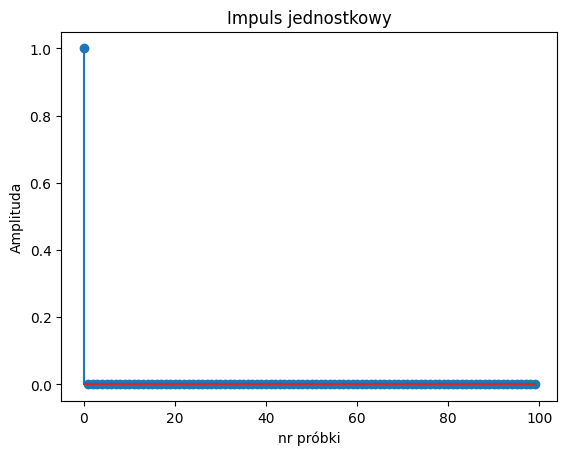

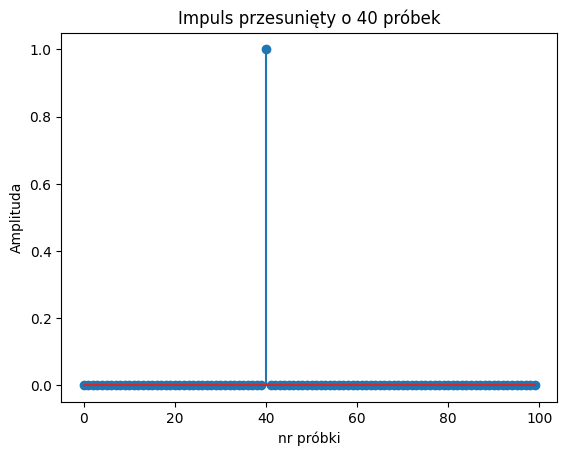

In [2]:
n = np.arange(0, 100)

delta = np.zeros(len(n))
delta[0] = 1


delta_shifted = np.zeros(len(n))
delta_shifted[40] = 1

plt.figure()
plt.title("Impuls jednostkowy")
plt.xlabel("nr próbki")
plt.ylabel("Amplituda")
plt.stem(n, delta)
plt.show()

plt.figure()
plt.title("Impuls przesunięty o 40 próbek")
plt.xlabel("nr próbki")
plt.ylabel("Amplituda")
plt.stem(n, delta_shifted)
plt.show()


## podpunkt b
```python

Text(0.5, 1.0, 'Przebieg prostokątny')

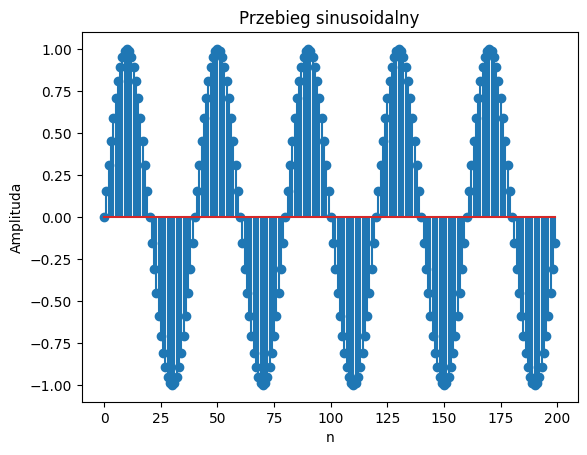

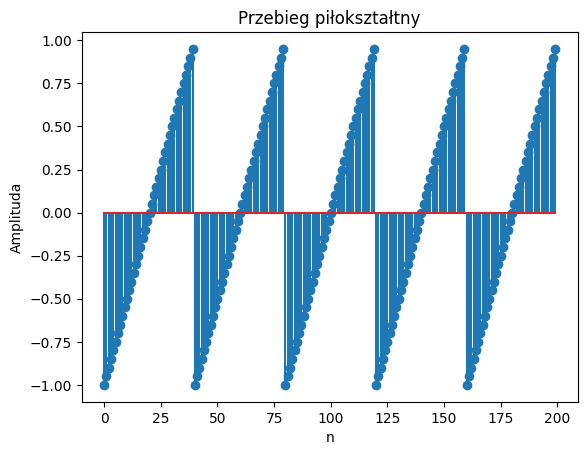

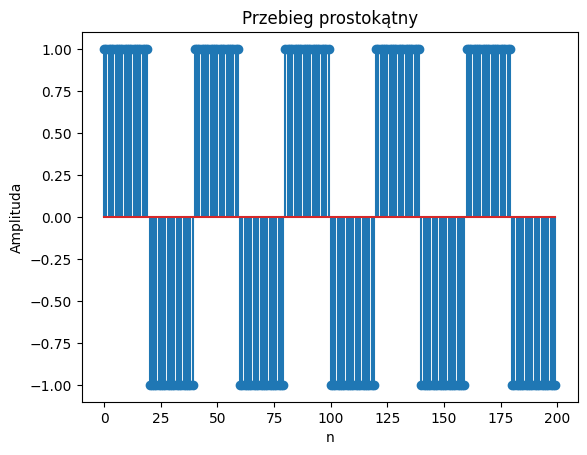

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

N = 200
okres = 5
f = okres / N

n=np.arange(N)

sinus=np.sin(2*np.pi*f*n)
piloksztaltny=signal.sawtooth(2*np.pi*f*n)
prostokatny=signal.square(2*np.pi*f*n)
trojkatny=signal.sawtooth(2*np.pi*f*n,0.5)

plt.figure()
plt.stem(n,sinus)
plt.xlabel("n")
plt.ylabel("Amplituda")
plt.title("Przebieg sinusoidalny")

plt.figure()
plt.stem(n,piloksztaltny)
plt.xlabel("n")
plt.ylabel("Amplituda")
plt.title("Przebieg piłokształtny")

plt.figure()
plt.stem(n,prostokatny)
plt.xlabel("n")
plt.ylabel("Amplituda")
plt.title("Przebieg prostokątny")

#plt.figure()
#plt.stem(n,trojkatny)
#plt.xlabel("n")
#plt.ylabel("Amplituda")
#plt.title("Przebieg trójkątny")


## podpunkt c
```python

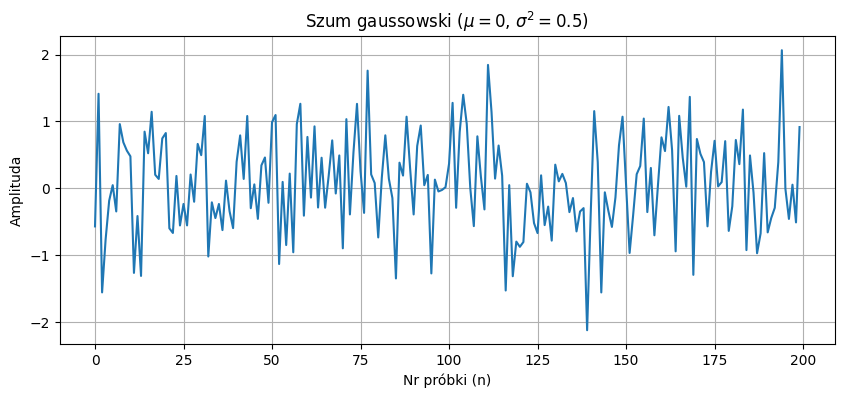

In [4]:
import numpy as np
import matplotlib.pyplot as plt

N=200
mi=0
wariancja=0.5

sigma=np.sqrt(wariancja)

szum=np.random.normal(mi,sigma,N)

plt.figure(figsize=(10, 4))
plt.plot(n, szum)
plt.title(r'Szum gaussowski ($\mu=0$, $\sigma^2=0.5$)')
plt.xlabel('Nr próbki (n)')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

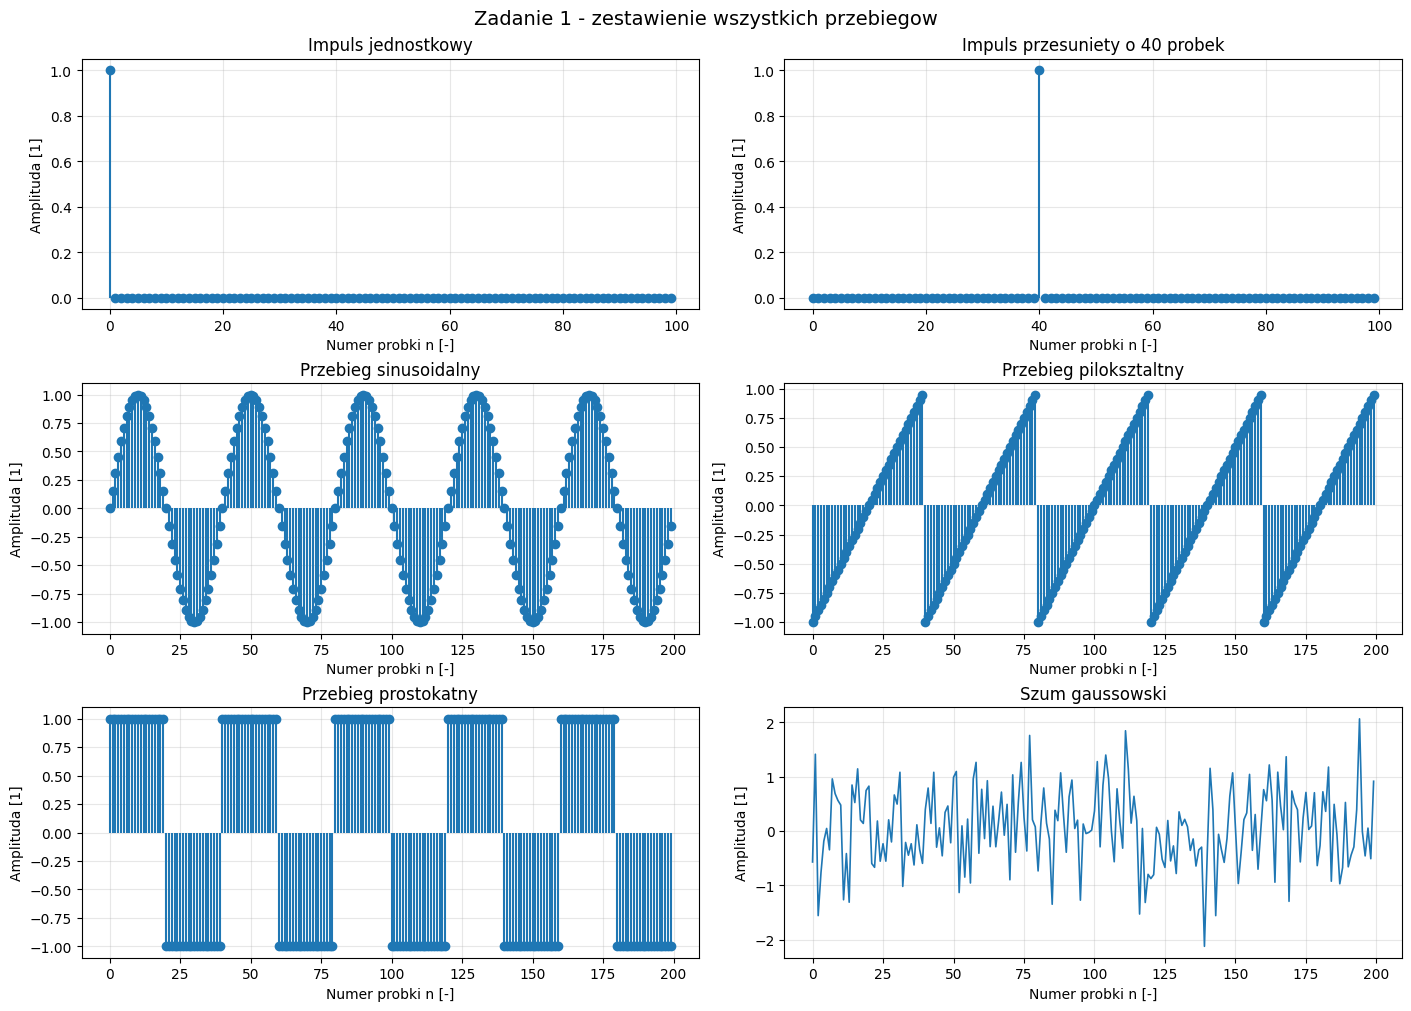

In [5]:
# Zbiorcze okno z wykresami z Zad. 1 (bez tworzenia sygnalow od nowa)
fig, axs = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle("Zadanie 1 - zestawienie wszystkich przebiegow", fontsize=14)

# Os n dla impulsow: wykorzystujemy istniejaca os probek i dopasowujemy dlugosc
n_imp = n[:len(delta)]

# Sinus z Zad.1 moze byc nadpisany funkcja w Zad.3 - wtedy pobieramy go z istniejacego wykresu
sinus_data = sinus if isinstance(sinus, np.ndarray) else None
if sinus_data is None:
    for fig_num in plt.get_fignums():
        old_fig = plt.figure(fig_num)
        if not old_fig.axes:
            continue
        ax_old = old_fig.axes[0]
        if ax_old.get_title() == "Przebieg sinusoidalny" and ax_old.lines:
            sinus_data = np.asarray(ax_old.lines[0].get_ydata())
            break

if sinus_data is None:
    raise RuntimeError("Brak danych przebiegu sinusoidalnego z Zad.1. Uruchom ponownie komorke podpunktu b.")

axs[0, 0].stem(n_imp, delta, basefmt=" ")
axs[0, 0].set_title("Impuls jednostkowy")
axs[0, 0].set_xlabel("Numer probki n [-]")
axs[0, 0].set_ylabel("Amplituda [1]")
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].stem(n_imp, delta_shifted, basefmt=" ")
axs[0, 1].set_title("Impuls przesuniety o 40 probek")
axs[0, 1].set_xlabel("Numer probki n [-]")
axs[0, 1].set_ylabel("Amplituda [1]")
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].stem(n, sinus_data, basefmt=" ")
axs[1, 0].set_title("Przebieg sinusoidalny")
axs[1, 0].set_xlabel("Numer probki n [-]")
axs[1, 0].set_ylabel("Amplituda [1]")
axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].stem(n, piloksztaltny, basefmt=" ")
axs[1, 1].set_title("Przebieg piloksztaltny")
axs[1, 1].set_xlabel("Numer probki n [-]")
axs[1, 1].set_ylabel("Amplituda [1]")
axs[1, 1].grid(True, alpha=0.3)

axs[2, 0].stem(n, prostokatny, basefmt=" ")
axs[2, 0].set_title("Przebieg prostokatny")
axs[2, 0].set_xlabel("Numer probki n [-]")
axs[2, 0].set_ylabel("Amplituda [1]")
axs[2, 0].grid(True, alpha=0.3)

axs[2, 1].plot(n, szum, linewidth=1.2)
axs[2, 1].set_title("Szum gaussowski")
axs[2, 1].set_xlabel("Numer probki n [-]")
axs[2, 1].set_ylabel("Amplituda [1]")
axs[2, 1].grid(True, alpha=0.3)

plt.show()

# Zad3

In [6]:
def sinus_z3(A, f, fi, fs, N):
    """
    A - amplituda
    f - czestotliwosc (Hz)
    fi - faza (w radianach)
    fs - probkowanie (Hz)
    N - liczba probek
    """
    n = np.arange(N)
    y = A * np.sin(2 * np.pi * f * n / fs + fi)
    return n, y

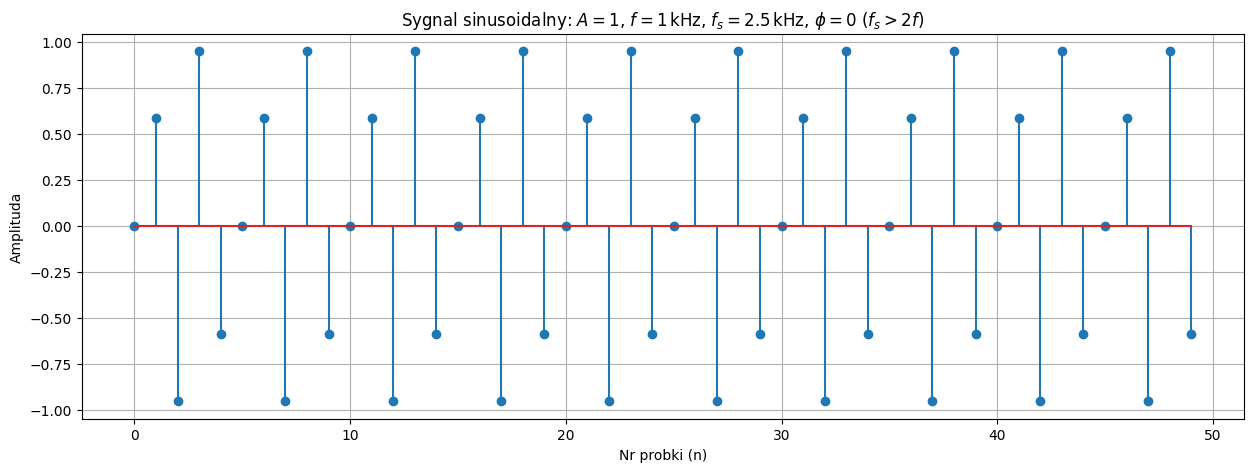

In [7]:
plt.figure(figsize=(15, 5))
plt.stem(*sinus_z3(1, 1000, 0, 2500, 50))
plt.title(r'Sygnal sinusoidalny: $A=1$, $f=1\,\mathrm{kHz}$, $f_s=2.5\,\mathrm{kHz}$, $\phi=0$ ($f_s > 2f$)')
plt.xlabel('Nr probki (n)')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

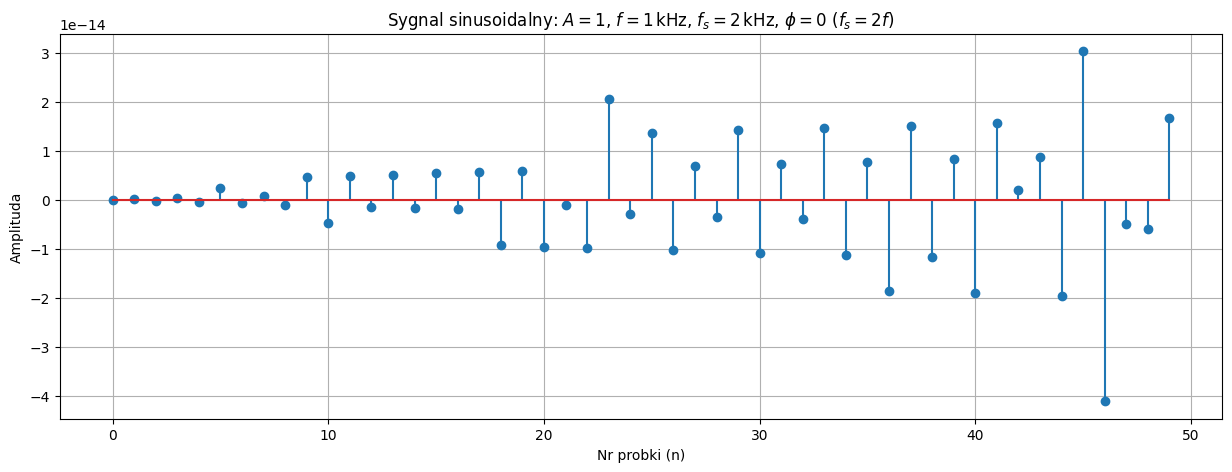

In [8]:
plt.figure(figsize=(15, 5))
plt.stem(*sinus_z3(1, 1000, 0, 2000, 50))
plt.title(r'Sygnal sinusoidalny: $A=1$, $f=1\,\mathrm{kHz}$, $f_s=2\,\mathrm{kHz}$, $\phi=0$ ($f_s = 2f$)')
plt.xlabel('Nr probki (n)')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

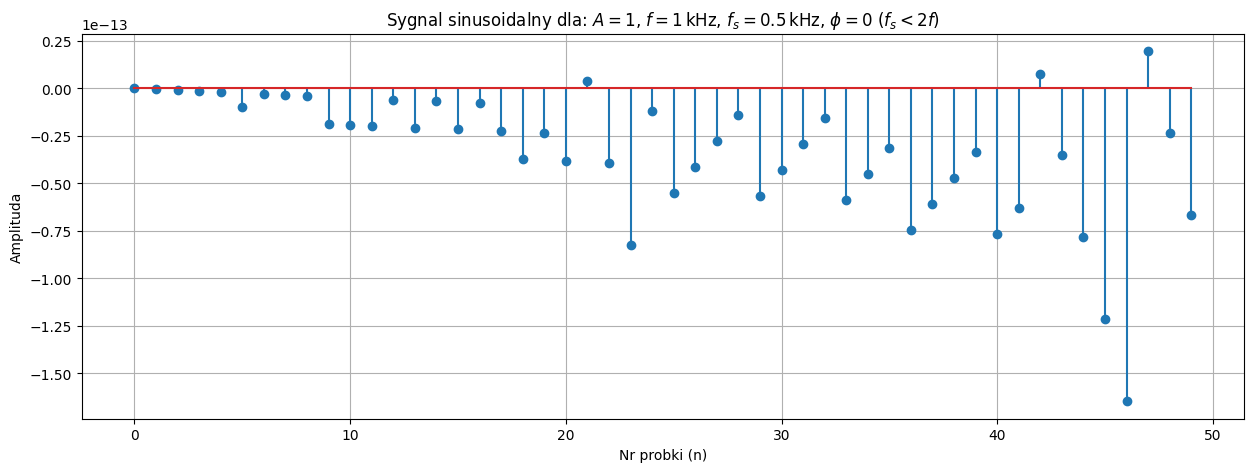

In [9]:
plt.figure(figsize=(15, 5))
plt.stem(*sinus_z3(1, 1000, 0, 500, 50))
plt.title(r'Sygnal sinusoidalny dla: $A=1$, $f=1\,\mathrm{kHz}$, $f_s=0.5\,\mathrm{kHz}$, $\phi=0$ ($f_s < 2f$)')
plt.xlabel('Nr probki (n)')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

---
# Zad4

/var/folders/1r/n1d7yxf13rj_r52hbv94t4x80000gn/T/ipykernel_8369/1649342004.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("nagranie.wav")


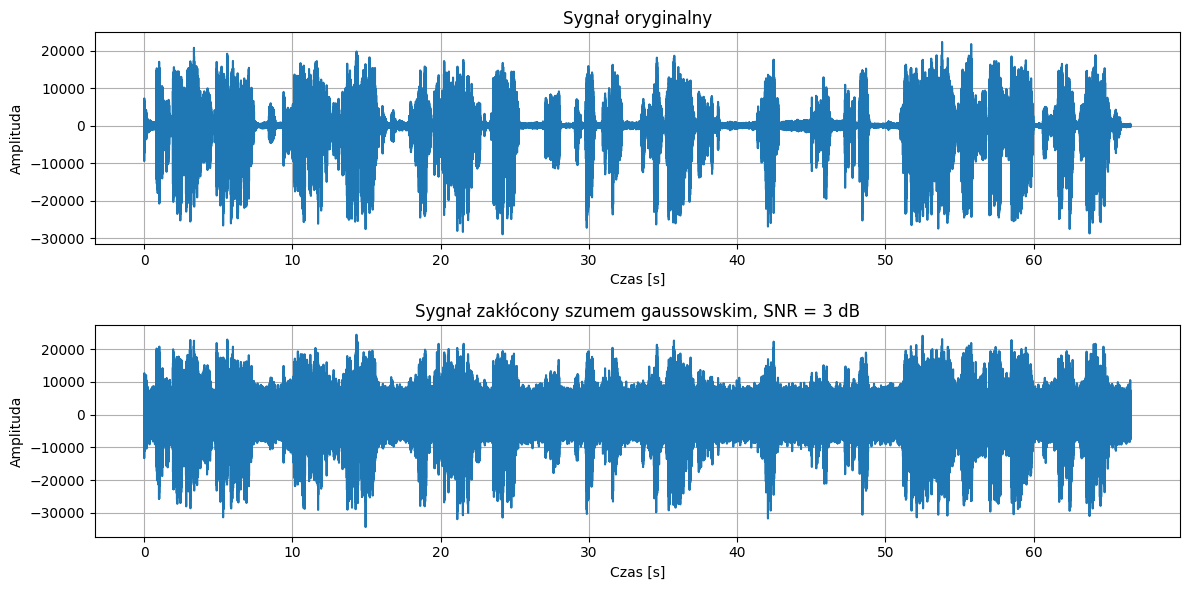

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

fs, x = wavfile.read("nagranie.wav")

x = x.astype(np.float64)

# jeśli nagranie jest stereo, bierzemy 1 kanał
if x.ndim > 1:
    x = x[:, 0]

# Generacja szumu gaussowskiego N(0,1)
noise = np.random.normal(0, 1, len(x))

# Obliczenie mocy sygnału i szumu
P_signal = np.mean(x**2)
P_noise = np.mean(noise**2)

# Ustawienie SNR = 3 dB
SNR_dB = 3
SNR_linear = 10**(SNR_dB / 10)

# chcemy: P_signal / P_noise_scaled = SNR_linear
# czyli: P_noise_scaled = P_signal / SNR_linear
# jeśli noise_scaled = a * noise, to:
# P_noise_scaled = a^2 * P_noise
# stąd:
a = np.sqrt(P_signal / (SNR_linear * P_noise))

noise_scaled = a * noise

# Superpozycja sygnału i szumu
y = x + noise_scaled

# Oś czasu
t = np.arange(len(x)) / fs

# Wykresy
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x)
plt.title("Sygnał oryginalny")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, y)
plt.title("Sygnał zakłócony szumem gaussowskim, SNR = 3 dB")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.grid()

plt.tight_layout()
plt.show()

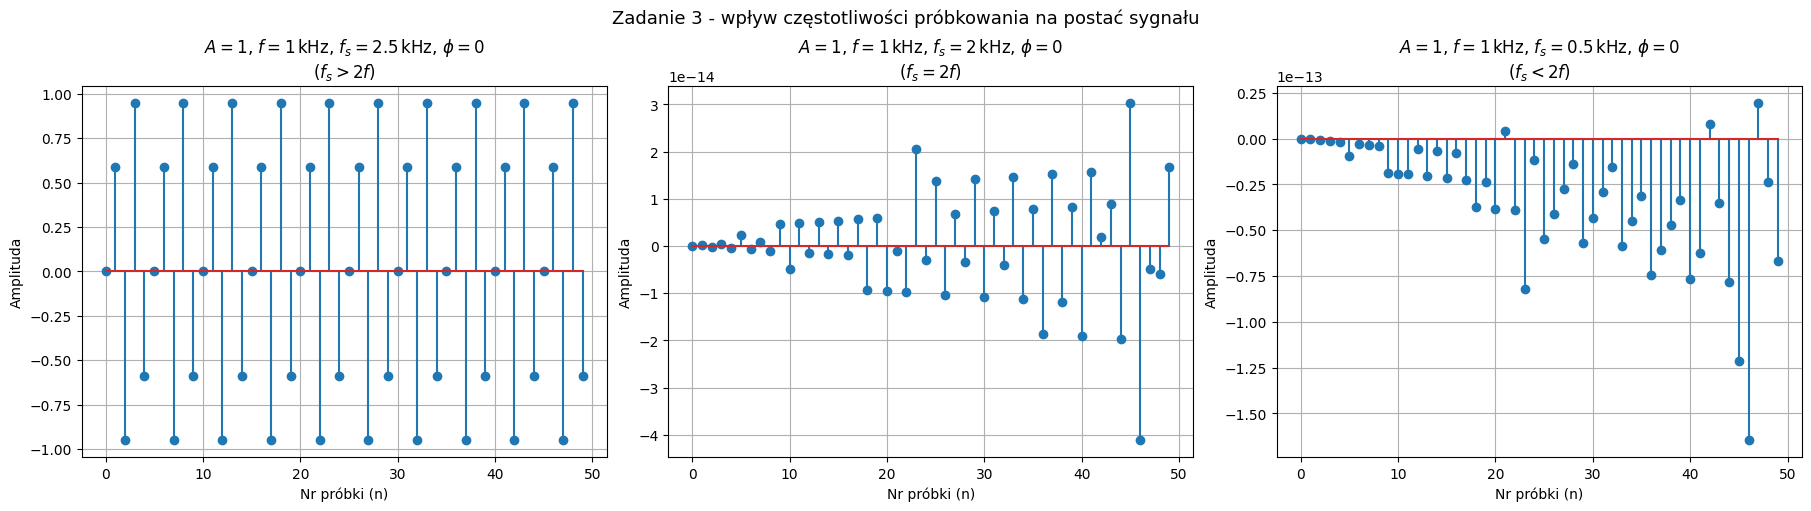

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Zadanie 3: próbkowanie sygnału sinusoidalnego
# =========================
def sinus_z3(A, f, fi, fs, N):
    """
    A  - amplituda sygnału
    f  - częstotliwość sygnału analogowego [Hz]
    fi - faza początkowa [rad]
    fs - częstotliwość próbkowania [Hz]
    N  - liczba próbek sygnału dyskretnego
    """
    n = np.arange(N)                                  # Wektor numerów próbek: n = 0, 1, ..., N-1
    y = A * np.sin(2 * np.pi * f * n / fs + fi)      # Dyskretyzacja sinusa: y[n] = A*sin(2πfn/fs + fi)
    return n, y


# =========================
# Zbiorcza prezentacja trzech przypadków relacji fs do 2f
# =========================
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle("Zadanie 3 - wpływ częstotliwości próbkowania na postać sygnału", fontsize=13)

# Przypadek 1: fs > 2f (spełnione kryterium Nyquista - poprawna reprezentacja)
axs[0].stem(*sinus_z3(1, 1000, 0, 2500, 50))
axs[0].set_title(r'$A=1$, $f=1\,\mathrm{kHz}$, $f_s=2.5\,\mathrm{kHz}$, $\phi=0$' + "\n" + r'($f_s > 2f$)')
axs[0].set_xlabel('Nr próbki (n)')
axs[0].set_ylabel('Amplituda')
axs[0].grid(True)                                     # Siatka pomocnicza dla lepszej czytelności wykresu

# Przypadek 2: fs = 2f (próbkowanie graniczne)
axs[1].stem(*sinus_z3(1, 1000, 0, 2000, 50))
axs[1].set_title(r'$A=1$, $f=1\,\mathrm{kHz}$, $f_s=2\,\mathrm{kHz}$, $\phi=0$' + "\n" + r'($f_s = 2f$)')
axs[1].set_xlabel('Nr próbki (n)')
axs[1].set_ylabel('Amplituda')
axs[1].grid(True)

# Przypadek 3: fs < 2f (niespełnione kryterium Nyquista - aliasing)
axs[2].stem(*sinus_z3(1, 1000, 0, 500, 50))
axs[2].set_title(r'$A=1$, $f=1\,\mathrm{kHz}$, $f_s=0.5\,\mathrm{kHz}$, $\phi=0$' + "\n" + r'($f_s < 2f$)')
axs[2].set_xlabel('Nr próbki (n)')
axs[2].set_ylabel('Amplituda')
axs[2].grid(True)

plt.show()

In [ ]:
# zad 2

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio,display

def sinus(A, f, fi, fs, N):
    """
    A - amplituda
    f - częstotliwość (Hz)
    fi - faza (w radianach)
    fs - próbkowanie (Hz)
    N - liczba próbek
    """
    n = np.arange(N)
    y = A * np.sin(2 * np.pi * f * n / fs + fi)
    return n, y

fs = 44100
duration = 2
N = int(fs * duration)

# zmiana amplitudy
n1,y1 = sinus(0.3, 440, 0, fs, N)
n2,y2 = sinus(0.8, 440, 0, fs, N)

# zmiana częstotliwości
n3,y3 = sinus(0.5, 220, 0, fs, N)
n4,y4 = sinus(0.5, 880, 0, fs, N)

# zmiana fazy
n5,y5 = sinus(0.5, 440, 0, fs, N)
n6,y6 = sinus(0.5, 440, np.pi/2, fs, N)

plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(n1[:1000], y1[:1000], label='A=0.3')
plt.plot(n2[:1000], y2[:1000], label='A=0.8')
plt.title("Wpływ amplitudy")
plt.legend()
plt.grid()

plt.subplot(3,1,2)
plt.plot(n3[:1000], y3[:1000], label='f=220')
plt.plot(n4[:1000], y4[:1000], label='f=880')
plt.title("Wpływ częstotliwości")
plt.legend()
plt.grid()

plt.subplot(3,1,3)
plt.plot(n5[:1000], y5[:1000], label='fi=0')
plt.plot(n6[:1000], y6[:1000], label='fi=pi/2')
plt.title("Wpływ fazy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


#odsłuchy

print("Amplituda:")
display(Audio(y1, rate=fs))
display(Audio(y2, rate=fs))

print("Częstotliwość:")
display(Audio(y3, rate=fs))
display(Audio(y4, rate=fs))

print("Faza:")
display(Audio(y5, rate=fs))
display(Audio(y6, rate=fs))

